Goal: double check that $\chi^2$ is working the way we think it should by manually inputting datapoints that are different sigma above or below the true data & checking that the value returned looks right

In [3]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata

In [4]:
# Create mock data that's a single datapoint so that we can tell if chi squared is working
mock_data = [10.0, 0.5, np.array([-20.75]), np.array([4.000e-6]), np.array([1.00e-5]), 
             np.array([3.00e-6]), np.array([0.5]), 'Donnan+24']
# MUV = -20.75, phi = 4e-6, upper y-err = 1e-5, lower y-err = 3e-6

In [5]:
param_data = eMCMC.build_param_data({})

In [6]:
test_UVLF = eMCMC.UVLF(sorted_data = [[mock_data]], param_data = param_data)

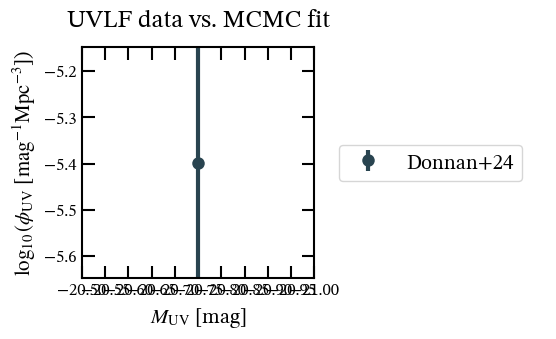

In [7]:
# Test that we really do have just one datapoint
test_fig = eplots.evolving_UVLF_fit(test_UVLF, plot_from_chain = False)

In [41]:
ydat = mock_data[3]
yerr_upper = mock_data[4]
yerr_lower = mock_data[5]
nsigma = 3
uvlftheory = ydat - nsigma*yerr_lower

yerr_asymmetrical = np.array([yerr_upper if uvlftheory > ydat else yerr_lower])

# this formula is just proportional to the natural log of a Gaussian
loglike = -np.sum((ydat - uvlftheory)**2/(2.0 * yerr_asymmetrical**2))
chi_squared = -2*loglike

In [54]:
print(f'chi**2 = {chi_squared} which should be equal to the number of sigma we are off, squared: {nsigma**2}')

chi**2 = 9.0 which should be equal to the number of sigma we are off, squared: 9


In [53]:
print(r'$\sigma$')

$\sigma$


red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


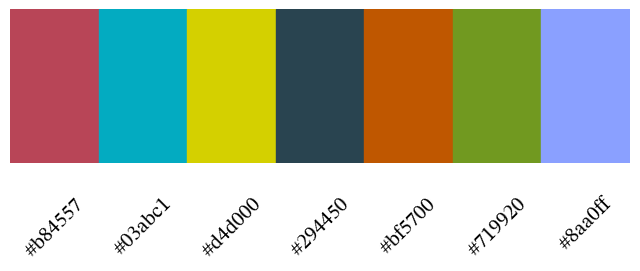

In [56]:
eplots.plot_colors()